# Proyecto completo de Machine Learning usando librerías

## Ejemplo didáctico: clasificación con Árbol de Decisión

Este notebook muestra, de manera básica y ordenada, las fases principales de un proyecto de Machine Learning usando librerías estándar de Python.

- `pandas` para manipulación de datos.
- `numpy` para operaciones numéricas.
- `matplotlib` y `seaborn` para visualización.
- `scikit-learn` para preprocesamiento, entrenamiento, validación, evaluación y afinamiento del modelo.

## Fases del proyecto

1. Carga del dataset.
2. Análisis exploratorio de datos — EDA.
3. Limpieza de datos.
4. Ingeniería de características.
5. Preparación de datos para entrenamiento.
6. Selección del modelo.
7. Entrenamiento.
8. Evaluación.
9. Validación con K-Fold Cross Validation.
10. Afinamiento con Grid Search.
11. Entrenamiento final del mejor modelo.
12. Interpretación básica del árbol.


## 1. Importación de librerías

En esta sección importamos las librerías necesarias para el proyecto.

> En Google Colab, `scikit-learn`, `pandas`, `numpy`, `matplotlib` y `seaborn` suelen venir instaladas por defecto.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")


## 2. Carga del dataset

Usaremos el dataset **Titanic**, un conjunto de datos clásico para clasificación.

El objetivo es predecir si un pasajero sobrevivió o no sobrevivió.

La variable objetivo será:

- `survived`: 1 si sobrevivió, 0 si no sobrevivió.


In [2]:
# Cargar Titanic desde OpenML
titanic = fetch_openml(name="titanic", version=1, as_frame=True)

df = titanic.frame.copy()

# Visualizar primeras filas
df.head()


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [3]:
# Tamaño del dataset
df.shape


(1309, 14)

In [4]:
# Información general del dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   str     
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   str     
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   category
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
dtypes: category(3), float64(3), int64(3), str(5)
memory usage: 116.6 KB


## 3. Análisis exploratorio de datos — EDA

El EDA permite conocer mejor los datos antes de entrenar el modelo.

Revisaremos:

- Primeras filas.
- Tipos de datos.
- Valores faltantes.
- Distribución de la variable objetivo.
- Relaciones básicas entre variables.


In [5]:
# Resumen estadístico de variables numéricas
df.describe()


,pclass,age,sibsp,parch,fare,body
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [6]:
# Cantidad de valores faltantes por columna
df.isnull().sum().sort_values(ascending=False)


body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
fare            1
sibsp           0
name            0
survived        0
pclass          0
sex             0
parch           0
ticket          0
dtype: int64

In [7]:
# Distribución de la variable objetivo
df["survived"].value_counts()


survived
0    809
1    500
Name: count, dtype: int64

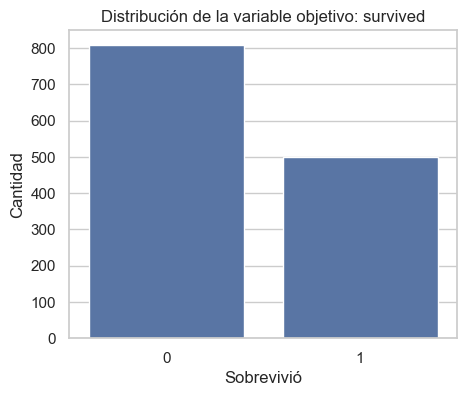

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="survived")
plt.title("Distribución de la variable objetivo: survived")
plt.xlabel("Sobrevivió")
plt.ylabel("Cantidad")
plt.show()


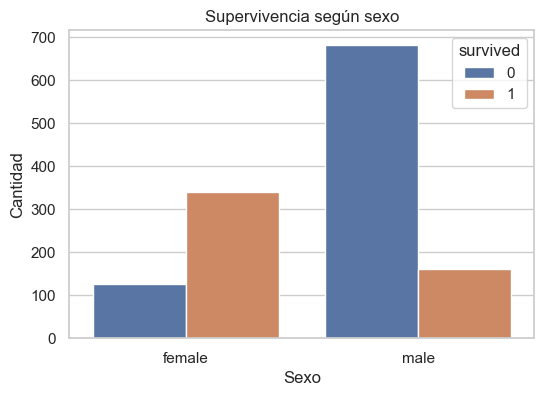

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Supervivencia según sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad")
plt.show()


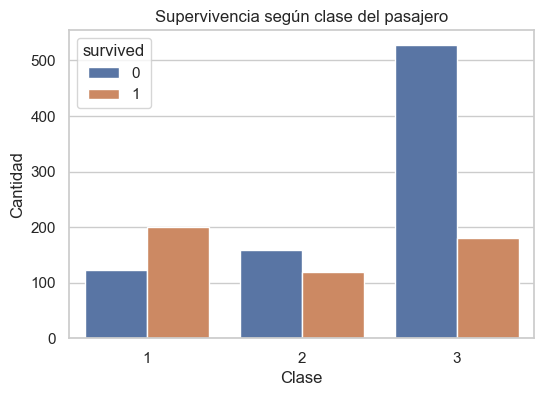

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="pclass", hue="survived")
plt.title("Supervivencia según clase del pasajero")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()


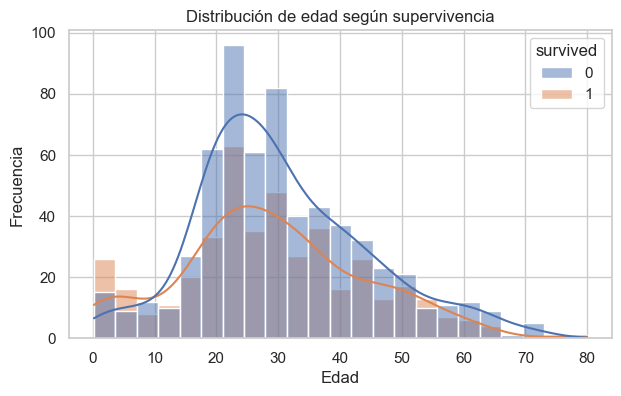

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="age", hue="survived", kde=True)
plt.title("Distribución de edad según supervivencia")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


## 4. Selección inicial de variables

Para mantener el ejemplo simple, seleccionaremos algunas variables relevantes.

Variables predictoras:

- `pclass`: clase del pasajero.
- `sex`: sexo.
- `age`: edad.
- `sibsp`: número de hermanos/esposos a bordo.
- `parch`: número de padres/hijos a bordo.
- `fare`: tarifa pagada.
- `embarked`: puerto de embarque.

Variable objetivo:

- `survived`.


In [12]:
columnas = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked", "survived"]

df_ml = df[columnas].copy()

df_ml.head()


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,1,female,29.0000,0,0,211.3375,S,1
1,1,male,0.9167,1,2,151.5500,S,1
2,1,female,2.0000,1,2,151.5500,S,0
3,1,male,30.0000,1,2,151.5500,S,0
4,1,female,25.0000,1,2,151.5500,S,0


## 5. Limpieza de datos

En un proyecto real, esta etapa puede incluir:

- Eliminar duplicados.
- Corregir tipos de datos.
- Tratar valores faltantes.
- Detectar valores atípicos.

En este notebook, haremos una limpieza básica:

- Eliminaremos duplicados si existen.
- Convertiremos la variable objetivo a tipo entero.
- Dejaremos que el pipeline trate los valores faltantes.


In [13]:
# Verificar duplicados
df_ml.duplicated().sum()


np.int64(195)

In [14]:
# Eliminar duplicados
df_ml = df_ml.drop_duplicates()

# Convertir variable objetivo a entero
df_ml["survived"] = df_ml["survived"].astype(int)

df_ml.info()


<class 'pandas.DataFrame'>
Index: 1114 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1114 non-null   int64   
 1   sex       1114 non-null   category
 2   age       974 non-null    float64 
 3   sibsp     1114 non-null   int64   
 4   parch     1114 non-null   int64   
 5   fare      1113 non-null   float64 
 6   embarked  1112 non-null   category
 7   survived  1114 non-null   int64   
dtypes: category(2), float64(2), int64(4)
memory usage: 63.1 KB


In [15]:
# Revisar valores faltantes después de seleccionar columnas
df_ml.isnull().sum()


pclass        0
sex           0
age         140
sibsp         0
parch         0
fare          1
embarked      2
survived      0
dtype: int64

## 6. Ingeniería de características

La ingeniería de características consiste en crear nuevas variables a partir de las existentes.

Crearemos dos variables simples:

- `family_size`: tamaño de la familia a bordo.
- `is_alone`: indica si el pasajero viajaba solo.

Estas variables se derivan de:

- `sibsp`
- `parch`


In [16]:
df_ml["family_size"] = df_ml["sibsp"] + df_ml["parch"] + 1
df_ml["is_alone"] = (df_ml["family_size"] == 1).astype(int)

df_ml.head()


,pclass,sex,age,sibsp,parch,fare,embarked,survived,family_size,is_alone
0,1,female,29.0000,0,0,211.3375,S,1,1,1
1,1,male,0.9167,1,2,151.5500,S,1,4,0
2,1,female,2.0000,1,2,151.5500,S,0,4,0
3,1,male,30.0000,1,2,151.5500,S,0,4,0
4,1,female,25.0000,1,2,151.5500,S,0,4,0


## 7. Separación de variables predictoras y variable objetivo

Separaremos el dataset en:

- `X`: variables predictoras.
- `y`: variable objetivo.


In [17]:
X = df_ml.drop("survived", axis=1)
y = df_ml["survived"]

X.head()


,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone
0,1,female,29.0000,0,0,211.3375,S,1,1
1,1,male,0.9167,1,2,151.5500,S,4,0
2,1,female,2.0000,1,2,151.5500,S,4,0
3,1,male,30.0000,1,2,151.5500,S,4,0
4,1,female,25.0000,1,2,151.5500,S,4,0


In [18]:
y.head()


0    1
1    1
2    0
3    0
4    0
Name: survived, dtype: int64

## 8. Identificación de variables numéricas y categóricas

Como el dataset contiene variables numéricas y categóricas, aplicaremos tratamientos distintos:

### Variables numéricas
- Imputación de valores faltantes usando la mediana.

### Variables categóricas
- Imputación de valores faltantes usando la categoría más frecuente.
- Codificación One-Hot Encoding.


In [19]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare", "family_size", "is_alone"]
categorical_features = ["sex", "embarked"]

numeric_features, categorical_features


(['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone'],
 ['sex', 'embarked'])

## 9. Construcción del pipeline de preprocesamiento

Usaremos `ColumnTransformer` para aplicar diferentes transformaciones según el tipo de variable.

Esto permite organizar mejor el flujo de trabajo y evitar errores.


In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 10. División en entrenamiento y prueba

Dividiremos los datos en:

- 80% para entrenamiento.
- 20% para prueba.

El conjunto de prueba se reserva para evaluar el desempeño final del modelo.


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((891, 9), (223, 9))

## 11. Selección del modelo

Usaremos un modelo de clasificación basado en Árbol de Decisión.

En este caso, ya no implementamos el árbol manualmente. Usamos la clase:

```python
DecisionTreeClassifier
```

de `scikit-learn`.


In [22]:
modelo_arbol = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

modelo_arbol


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

## 12. Creación del pipeline completo

El pipeline completo integra:

1. Preprocesamiento.
2. Modelo de clasificación.

Esto permite entrenar el flujo completo con una sola instrucción.


In [23]:
pipeline_modelo = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", modelo_arbol)
])

pipeline_modelo


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 13. Entrenamiento del modelo

Ahora entrenamos el modelo usando los datos de entrenamiento.


In [24]:
pipeline_modelo.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 14. Predicción

Usamos el modelo entrenado para predecir sobre el conjunto de prueba.


In [25]:
y_pred = pipeline_modelo.predict(X_test)

y_pred[:10]


array([1, 0, 0, 0, 1, 1, 0, 0, 1, 0])

## 15. Evaluación del modelo

Evaluaremos el modelo usando Accuracy, matriz de confusión, Precision, Recall y F1-score.


In [26]:
accuracy = accuracy_score(y_test, y_pred)
accuracy


0.8116591928251121

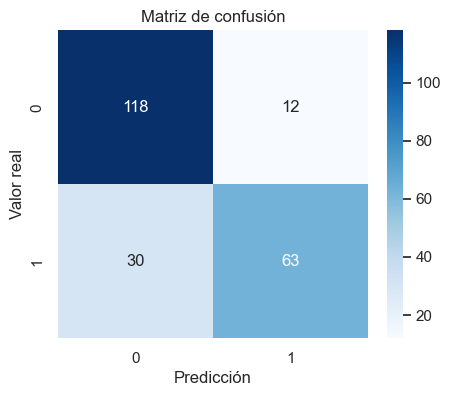

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


In [28]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.91      0.85       130
           1       0.84      0.68      0.75        93

    accuracy                           0.81       223
   macro avg       0.82      0.79      0.80       223
weighted avg       0.82      0.81      0.81       223



## 16. Validación con K-Fold Cross Validation

La validación cruzada permite evaluar el modelo de forma más robusta.

En K-Fold:

1. Se divide el dataset en K partes.
2. El modelo se entrena K veces.
3. En cada iteración, una parte se usa para validación y las demás para entrenamiento.
4. Al final, se calcula el promedio de desempeño.

Usaremos `K = 5`.


In [29]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline_modelo,
    X,
    y,
    cv=kfold,
    scoring="accuracy"
)

scores


array([0.75336323, 0.77130045, 0.79372197, 0.8161435 , 0.77927928])

In [30]:
print("Accuracy por fold:", scores)
print("Accuracy promedio:", scores.mean())
print("Desviación estándar:", scores.std())


Accuracy por fold: [0.75336323 0.77130045 0.79372197 0.8161435  0.77927928]
Accuracy promedio: 0.7827616854522684
Desviación estándar: 0.021176542041903303


## 17. Afinamiento del modelo con Grid Search

El Grid Search prueba varias combinaciones de hiperparámetros para encontrar la mejor configuración.

En este caso afinaremos:

- `criterion`: criterio de división del árbol.
- `max_depth`: profundidad máxima del árbol.
- `min_samples_split`: mínimo de muestras para dividir un nodo.
- `min_samples_leaf`: mínimo de muestras en una hoja.


In [31]:
param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [2, 3, 4, 5, 6, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=pipeline_modelo,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [2, 3, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messag

In [32]:
grid_search.best_params_


{'classifier__criterion': 'gini',
 'classifier__max_depth': 4,
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 2}

In [33]:
grid_search.best_score_


np.float64(0.7744209403050656)

## 18. Evaluación del mejor modelo

Luego de encontrar la mejor combinación de hiperparámetros, evaluamos el mejor modelo sobre el conjunto de prueba.


In [34]:
mejor_modelo = grid_search.best_estimator_

y_pred_best = mejor_modelo.predict(X_test)

accuracy_best = accuracy_score(y_test, y_pred_best)

accuracy_best


0.8116591928251121

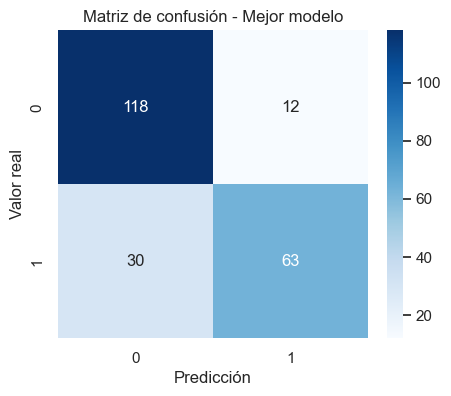

In [35]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Mejor modelo")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


In [36]:
print(classification_report(y_test, y_pred_best))


              precision    recall  f1-score   support

           0       0.80      0.91      0.85       130
           1       0.84      0.68      0.75        93

    accuracy                           0.81       223
   macro avg       0.82      0.79      0.80       223
weighted avg       0.82      0.81      0.81       223



## 19. Comparación entre modelo inicial y modelo afinado

Compararemos el accuracy del modelo inicial y del modelo optimizado con Grid Search.


In [37]:
resultados = pd.DataFrame({
    "Modelo": ["Árbol inicial", "Árbol con Grid Search"],
    "Accuracy en prueba": [accuracy, accuracy_best]
})

resultados


,Modelo,Accuracy en prueba
0,Árbol inicial,0.811659
1,Árbol con Grid Search,0.811659


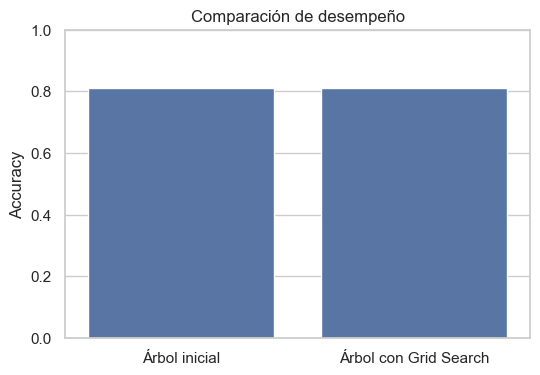

In [38]:
plt.figure(figsize=(6,4))
sns.barplot(data=resultados, x="Modelo", y="Accuracy en prueba")
plt.ylim(0, 1)
plt.title("Comparación de desempeño")
plt.ylabel("Accuracy")
plt.xlabel("")
plt.show()


## 20. Visualización del árbol de decisión

Para visualizar el árbol, necesitamos acceder al modelo entrenado dentro del pipeline.

Además, debemos obtener los nombres finales de las variables después del preprocesamiento.


In [39]:
# Obtener nombres de variables después del One-Hot Encoding
preprocessor_entrenado = mejor_modelo.named_steps["preprocessor"]

cat_names = preprocessor_entrenado.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)

feature_names = numeric_features + list(cat_names)

feature_names


['pclass',
 'age',
 'sibsp',
 'parch',
 'fare',
 'family_size',
 'is_alone',
 'sex_female',
 'sex_male',
 'embarked_C',
 'embarked_Q',
 'embarked_S']

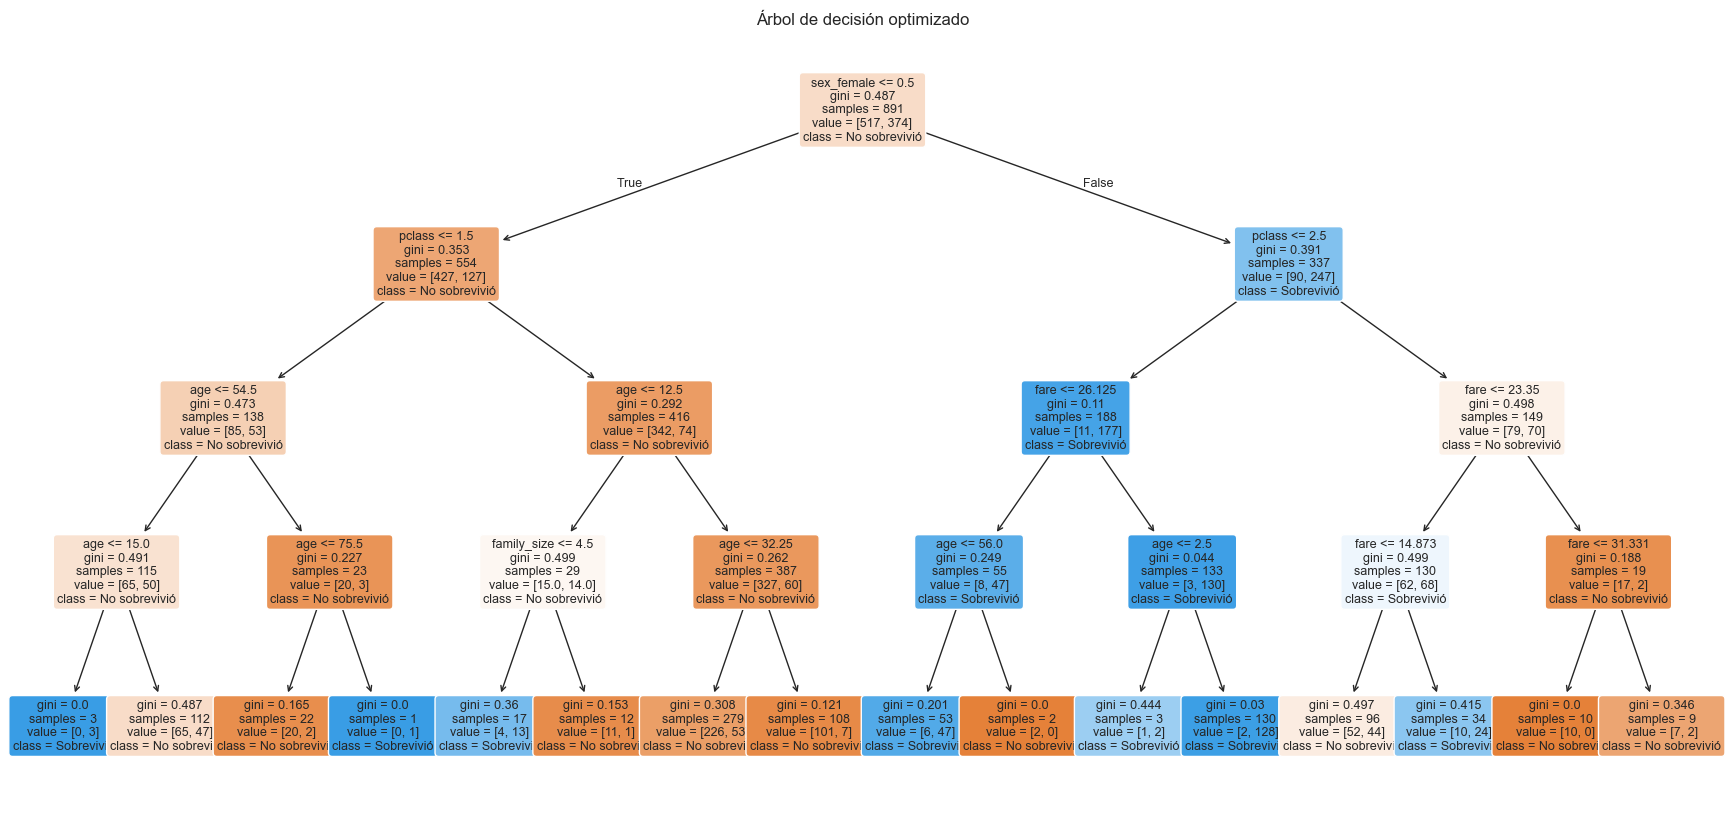

In [40]:
arbol_entrenado = mejor_modelo.named_steps["classifier"]

plt.figure(figsize=(22,10))
plot_tree(
    arbol_entrenado,
    feature_names=feature_names,
    class_names=["No sobrevivió", "Sobrevivió"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Árbol de decisión optimizado")
plt.show()


## 21. Importancia de características

Los árboles de decisión permiten estimar la importancia relativa de cada variable en la predicción.


In [41]:
importancias = pd.DataFrame({
    "feature": feature_names,
    "importance": arbol_entrenado.feature_importances_
}).sort_values(by="importance", ascending=False)

importancias


,feature,importance
7,sex_female,0.565193
0,pclass,0.243450
1,age,0.100776
4,fare,0.055859
5,family_size,0.034722
2,sibsp,0.000000
3,parch,0.000000
6,is_alone,0.000000
8,sex_male,0.000000
9,embarked_C,0.000000


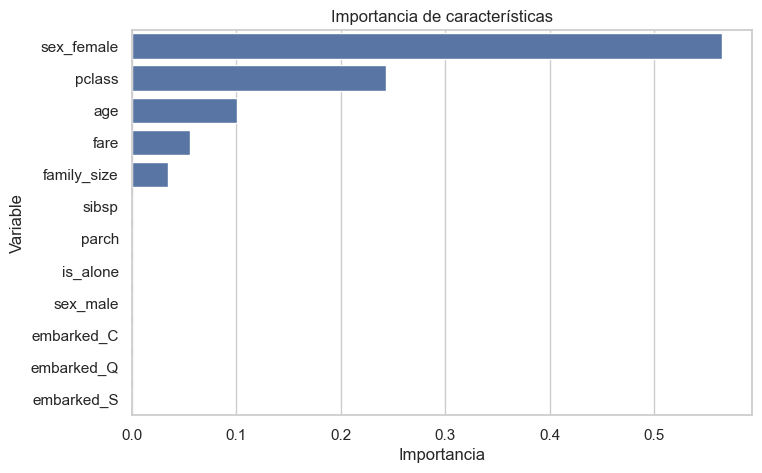

In [42]:
plt.figure(figsize=(8,5))
sns.barplot(data=importancias, x="importance", y="feature")
plt.title("Importancia de características")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


## 22. Conclusiones del proyecto

En este notebook se desarrolló un proyecto básico de Machine Learning usando librerías.

Se trabajaron las siguientes fases:

1. Carga del dataset.
2. Análisis exploratorio de datos.
3. Limpieza básica.
4. Ingeniería de características.
5. Preprocesamiento con `Pipeline` y `ColumnTransformer`.
6. Selección de un Árbol de Decisión.
7. Entrenamiento del modelo.
8. Evaluación con métricas de clasificación.
9. Validación cruzada K-Fold.
10. Afinamiento con Grid Search.
11. Visualización e interpretación del árbol.

## Idea central

En un proyecto real de Machine Learning no basta con entrenar un modelo.  
También es necesario preparar correctamente los datos, validar el desempeño y ajustar los hiperparámetros.
